In [11]:
import os
import pandas as pd

# Define input folder
input_folder = "Attribution Scores 1.5 Final"

# Initialize list to collect statistics
stats_list = []

# Loop over all CSVs in the folder
for filename in os.listdir(input_folder):
    if filename.endswith(".csv") and filename.startswith("MedBullets_df_op4_Q"):
        filepath = os.path.join(input_folder, filename)
        
        try:
            df = pd.read_csv(filepath)

            # Check if necessary columns exist
            if "Score" in df.columns and "Extracted_Answer" in df.columns:
                mean_score = df["Score"].mean()
                std_score = df["Score"].std()
                extracted_answer = df["Extracted_Answer"].dropna().astype(str).iloc[0] if not df["Extracted_Answer"].dropna().empty else None

                stats_list.append({
                    "QA_ID": filename.replace(".csv", ""),
                    "Mean_Score": mean_score,
                    "Std_Score": std_score,
                    "Extracted_Answer": extracted_answer
                })
            else:
                print(f"⚠️ Skipped {filename} (missing 'Score' or 'Extracted_Answer' column)")

        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")

# Create summary DataFrame
stats_df = pd.DataFrame(stats_list)

# Display the first few rows
stats_df.head(30)
print(len(stats_df))

297


In [18]:
# Add new columns: 1 std above and below the mean
stats_df["Upper_Threshold"] = stats_df["Mean_Score"] + stats_df["Std_Score"]
stats_df["Lower_Threshold"] = stats_df["Mean_Score"] - stats_df["Std_Score"]

# Display updated DataFrame
stats_df.head()


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold,Highly Relevant,Low Relevant,Irrelevant,QA_Index,Ground_Truth_Answer,Answer_Match
0,MedBullets_df_op4_Q136,20.611704,19.011731,C,39.623436,1.599973,0.444444,0.555556,0.000000,135,C,True
1,MedBullets_df_op4_Q221,34.216058,33.700289,D,67.916347,0.515768,0.272727,0.454545,0.272727,220,D,True
2,MedBullets_df_op4_Q22,39.904817,21.828645,B,61.733462,18.076171,0.000000,0.714286,0.285714,21,A,False
3,MedBullets_df_op4_Q305,34.920427,26.683389,B,61.603816,8.237038,0.166667,0.583333,0.250000,304,NaN,False
4,MedBullets_df_op4_Q25,33.553730,50.401330,A,83.955060,-16.847600,0.200000,0.800000,0.000000,24,C,False


In [19]:
import os
import pandas as pd

# Initialize relevance columns with zero
stats_df["Highly Relevant"] = 0
stats_df["Low Relevant"] = 0
stats_df["Irrelevant"] = 0

# Define input directory
input_folder = "Attribution Scores"

# Process each QA file and compute relevance categories
for i, row in stats_df.iterrows():
    qa_id = row["QA_ID"]
    file_path = os.path.join(input_folder, f"{qa_id}.csv")

    try:
        df = pd.read_csv(file_path)

        if "Score" in df.columns:
            scores = df["Score"]

            # Count relevance categories based on thresholds
            high_count = (scores > row["Upper_Threshold"]).sum()
            low_count = ((scores >= row["Lower_Threshold"]) & (scores <= row["Upper_Threshold"]) & (scores != 0)).sum()
            zero_count = (scores == 0).sum()

            # Update stats_df with raw counts
            stats_df.at[i, "Highly Relevant"] = high_count
            stats_df.at[i, "Low Relevant"] = low_count
            stats_df.at[i, "Irrelevant"] = zero_count
        else:
            print(f"⚠️ Skipped {qa_id}.csv — 'Score' column not found.")

    except Exception as e:
        print(f"❌ Error processing {qa_id}.csv: {e}")

# Normalize counts into proportions
relevance_cols = ["Highly Relevant", "Low Relevant", "Irrelevant"]
relevance_totals = stats_df[relevance_cols].sum(axis=1)

for col in relevance_cols:
    stats_df[col] = stats_df[col] / relevance_totals

# Preview results
stats_df.head(5)


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold,Highly Relevant,Low Relevant,Irrelevant,QA_Index,Ground_Truth_Answer,Answer_Match
0,MedBullets_df_op4_Q136,20.611704,19.011731,C,39.623436,1.599973,0.444444,0.555556,0.000000,135,C,True
1,MedBullets_df_op4_Q221,34.216058,33.700289,D,67.916347,0.515768,0.272727,0.454545,0.272727,220,D,True
2,MedBullets_df_op4_Q22,39.904817,21.828645,B,61.733462,18.076171,0.000000,0.714286,0.285714,21,A,False
3,MedBullets_df_op4_Q305,34.920427,26.683389,B,61.603816,8.237038,0.166667,0.583333,0.250000,304,NaN,False
4,MedBullets_df_op4_Q25,33.553730,50.401330,A,83.955060,-16.847600,0.200000,0.800000,0.000000,24,C,False


In [20]:
# Reshape the DataFrame for analysis
df_long = stats_df[["Highly Relevant", "Low Relevant", "Irrelevant"]].reset_index().melt(
    id_vars="index", 
    var_name="RelevanceCategory", 
    value_name="Proportion"
)
df_long = df_long.rename(columns={"index": "Subject"})

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit the repeated-measures ANOVA model
model = ols("Proportion ~ C(RelevanceCategory) + C(Subject)", data=df_long).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_long["Proportion"],
                          groups=df_long["RelevanceCategory"],
                          alpha=0.05)
print(tukey)


                            sum_sq     df             F        PR(>F)
C(RelevanceCategory)  2.331115e+01    2.0  1.383223e+02  5.473020e-50
C(Subject)            6.733676e-28  296.0  2.699723e-29  1.000000e+00
Residual              4.971567e+01  590.0           NaN           NaN
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
     group1        group2    meandiff p-adj lower upper reject
--------------------------------------------------------------
Highly Relevant   Irrelevant      nan   nan   nan   nan  False
Highly Relevant Low Relevant      nan   nan   nan   nan  False
     Irrelevant Low Relevant      nan   nan   nan   nan  False
--------------------------------------------------------------


/data/healthy-ml/scratch/yuexing/hf_env/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 296, but rank is 295
  warnings.warn('covariance of constraints does not have full '


/tmp/ipykernel_4139104/3095877642.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6)


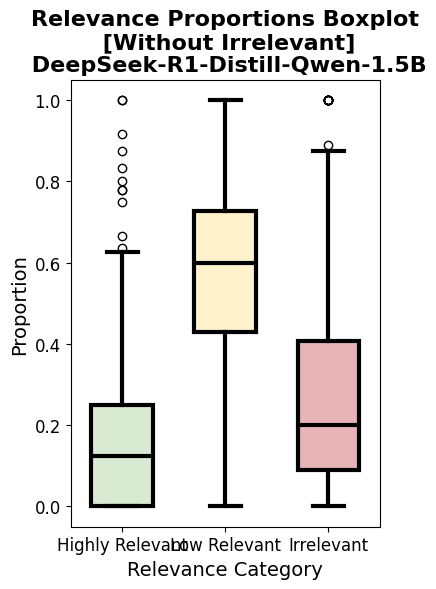

In [15]:
import matplotlib.pyplot as plt

# HEX colors sampled from your visual legend
color_high = "#d9ead3"        # Highly Relevant
color_low = "#fff2cc"         # Low Relevant
color_irrel = "#e8b4b8"       # Irrelevant

# Prepare the data
data = [
    stats_df["Highly Relevant"].dropna(),
    stats_df["Low Relevant"].dropna(),
    stats_df["Irrelevant"].dropna()
]

labels = ["Highly Relevant", "Low Relevant", "Irrelevant"]
colors = [color_high, color_low, color_irrel]

# Create the boxplot
fig, ax = plt.subplots(figsize=(4, 6))
bp = ax.boxplot(data, patch_artist=True, labels=labels, widths=0.6)

# Apply colors and formatting
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_linewidth(3)

for whisker in bp["whiskers"]:
    whisker.set_linewidth(3)
for cap in bp["caps"]:
    cap.set_linewidth(3)
for median in bp["medians"]:
    median.set_linewidth(3)
    median.set_color("black")

# Customize text and layout
ax.set_title("Relevance Proportions Boxplot\n [Without Irrelevant]\n DeepSeek-R1-Distill-Qwen-1.5B", fontsize=16, weight='bold')
ax.set_ylabel("Proportion", fontsize=14)
ax.set_xlabel("Relevance Category", fontsize=14)
ax.tick_params(axis='both', labelsize=12)

# Export
plt.tight_layout()
plt.savefig("qwen1.5b_relevance_boxplot_remove_irrelevant.pdf", dpi=300)
plt.show()


## Compare the Results

In [16]:
# Load the medbullets ground truth file
truth_df = pd.read_csv("medbullets_4o_reasoning_results.csv")

# Strip and upper-case for reliable comparison
truth_df["answer_idx"] = truth_df["answer_idx"].astype(str).str.strip().str.upper()
stats_df["Extracted_Answer"] = stats_df["Extracted_Answer"].astype(str).str.strip().str.upper()

# Extract numeric index from QA_ID
stats_df["QA_Index"] = stats_df["QA_ID"].str.extract(r"Q(\d+)", expand=False).astype(int) - 1  # 0-based indexing

# Map ground truth answer
stats_df["Ground_Truth_Answer"] = stats_df["QA_Index"].map(truth_df["answer_idx"])

# Mark match status (will still include 'NONE' for now)
stats_df["Answer_Match"] = stats_df["Extracted_Answer"] == stats_df["Ground_Truth_Answer"]

# Exclude rows where Extracted_Answer is "NONE" from accuracy calculation
valid_mask = stats_df["Extracted_Answer"].str.upper() != "NONE"
valid_answers = stats_df[valid_mask]
excluded_count = len(stats_df) - len(valid_answers)

# Calculate and print accuracy
accuracy = (valid_answers["Extracted_Answer"] == valid_answers["Ground_Truth_Answer"]).mean()
print(f"Accuracy (excluding 'NONE'): {accuracy * 100:.1f}%")
print(f"Excluded {excluded_count} rows with 'Extracted_Answer' as 'NONE'.")

# Preview mismatches (optional)
mismatches = valid_answers[valid_answers["Answer_Match"] == False]

# Sort by QA number
stats_df_sorted = stats_df.sort_values("QA_Index").reset_index(drop=True)

# Display top rows
stats_df_sorted.head(5)


Accuracy (excluding 'NONE'): 22.7%
Excluded 50 rows with 'Extracted_Answer' as 'NONE'.


,QA_ID,Mean_Score,Std_Score,Extracted_Answer,Upper_Threshold,Lower_Threshold,Highly Relevant,Low Relevant,Irrelevant,QA_Index,Ground_Truth_Answer,Answer_Match
0,MedBullets_df_op4_Q2,11.556225,27.604340,NONE,39.160565,-16.048115,0.272727,0.727273,0.000000,1,B,False
1,MedBullets_df_op4_Q3,44.864106,55.259892,D,100.123998,-10.395786,0.125000,0.500000,0.375000,2,A,False
2,MedBullets_df_op4_Q4,23.784392,25.855261,NONE,49.639653,-2.070869,0.166667,0.833333,0.000000,3,D,False
3,MedBullets_df_op4_Q5,38.422661,42.307573,A,80.730234,-3.884912,0.181818,0.636364,0.181818,4,A,True
4,MedBullets_df_op4_Q6,54.160192,34.218728,A,88.378920,19.941463,0.166667,0.666667,0.166667,5,C,False


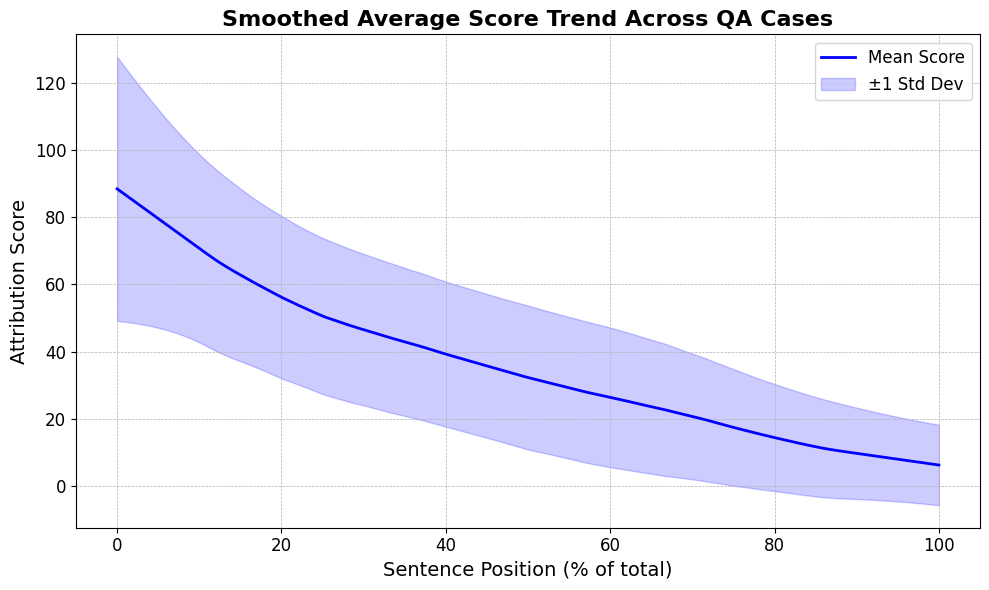

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Input folder
input_folder = "Attribution Scores 1.5 Final"

# Get all QA files
qa_files = sorted([f for f in os.listdir(input_folder) if f.endswith(".csv") and f.startswith("MedBullets_df_op4_Q")])

# Container for aligned score series
interpolated_scores = []

for filename in qa_files:
    filepath = os.path.join(input_folder, filename)
    try:
        df = pd.read_csv(filepath)
        if "Score" in df.columns:
            scores = df["Score"].dropna().values
            if len(scores) > 1:
                # Interpolate each to 100 points across 0–100%
                interp_scores = np.interp(np.linspace(0, len(scores) - 1, 100), np.arange(len(scores)), scores)
                interpolated_scores.append(interp_scores)
    except Exception as e:
        print(f"❌ Error with {filename}: {e}")

# Convert to matrix
score_matrix = np.vstack(interpolated_scores)
mean_scores = score_matrix.mean(axis=0)
std_scores = score_matrix.std(axis=0)
x = np.linspace(0, 100, 100)

# Plot mean ± std
plt.figure(figsize=(10, 6))
plt.plot(x, mean_scores, color="blue", linewidth=2, label="Mean Score")
plt.fill_between(x, mean_scores - std_scores, mean_scores + std_scores, color="blue", alpha=0.2, label="±1 Std Dev")

plt.title("Smoothed Average Score Trend Across QA Cases", fontsize=16, weight='bold')
plt.xlabel("Sentence Position (% of total)", fontsize=14)
plt.ylabel("Attribution Score", fontsize=14)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
